In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Student_performance_data _.csv')

In [3]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
df.drop('StudentID',axis=1,inplace=True)

In [7]:
from sklearn.preprocessing import StandardScaler

In [11]:
my_scaler = StandardScaler()

In [12]:
my_scaler.fit_transform(df)

array([[ 0.47291901,  0.97849211, -0.85339088, ..., -0.43186565,
         1.11808631, -0.79738659],
       [ 1.36294441, -1.02198065, -0.85339088, ..., -0.43186565,
         1.24237446, -1.60798953],
       [-1.30713178, -1.02198065,  1.09164102, ..., -0.43186565,
        -1.96027719,  0.82381929],
       ...,
       [-0.41710638,  0.97849211, -0.85339088, ...,  2.31553495,
        -0.83484487, -0.79738659],
       [-0.41710638,  0.97849211,  0.11912507, ..., -0.43186565,
        -0.11245195, -1.60798953],
       [-0.41710638,  0.97849211, -0.85339088, ...,  2.31553495,
         0.25555918, -1.60798953]])

In [13]:
x_scale=my_scaler.fit_transform(df)

In [17]:
from sklearn.cluster import KMeans

In [18]:
kmeans_model = KMeans(n_clusters=3)

In [19]:
kmeans_model.fit_predict(x_scale)

array([0, 1, 2, ..., 2, 1, 1], dtype=int32)

In [20]:
df['Clusters'] = kmeans_model.fit_predict(x_scale)

In [21]:
df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Clusters
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,2
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,2
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,1
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0,2
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0,2
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0,0
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0,2


### Using Elbo Method to Determine Clusters

In [24]:
result = []

for k in range(1,11):
    kmeans_model = KMeans(n_clusters=k,random_state=42)
    kmeans_model.fit(x_scale)
    result.append(kmeans_model.inertia_)

In [25]:
result

[33487.99999999999,
 28686.04172855558,
 27017.637498613647,
 25703.42108682782,
 24886.3737827722,
 24208.00590940025,
 23530.383260605224,
 22741.30068256646,
 22422.869225302853,
 21726.16115798738]

In [28]:
from matplotlib import pyplot as plt

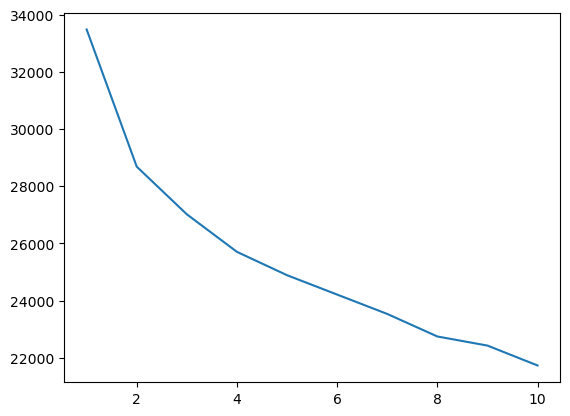

In [29]:
plt.plot(range(1,11),result)

In [30]:
# To Save This Graph We do

In [31]:
plt.savefig('elbow chart')

<Figure size 640x480 with 0 Axes>

In [32]:
# From Chat best cluster is 4 so we repeat


In [33]:
kmeans_model = KMeans(n_clusters=4)

In [34]:
df['Clusters'] = kmeans_model.fit_predict(x_scale)

In [35]:
df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Clusters
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,2
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,3
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,3
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0,3
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0,2
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0,1
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0,3


In [43]:
import joblib as j

In [48]:
j.dump(kmeans_model, 'kmeans.pkl')

['kmeans.pkl']

In [47]:
j.dump(my_scaler,'mystandard_scaler.pkl')

['mystandard_scaler.pkl']

In [46]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA', 'GradeClass', 'Clusters'],
      dtype='object')